This block imports all the necessary libraries for data manipulation, visualization, and machine learning. `numpy` and `pandas` are for numerical operations and data structuring, `matplotlib` and `mpl_toolkits` are for plotting, `sklearn.model_selection` for data splitting, `sklearn.svm` for Support Vector Machine models, and `matplotlib.colors` for color mapping in plots.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

This code generates a synthetic dataset using `make_circles` from `sklearn.datasets`. This dataset is specifically designed to be non-linearly separable, which is a classic scenario where kernel methods like SVMs shine. It then visualizes this 2D data using a scatter plot, coloring points based on their class (`y`) to show the circular separation.

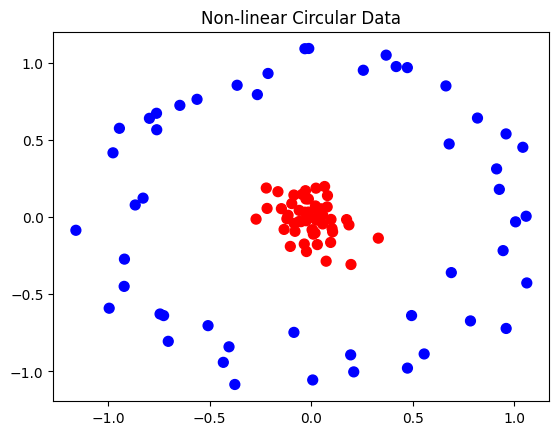

In [21]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
X, y = make_circles(n_samples=100, factor=0.1, noise=0.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.title("Non-linear Circular Data")
plt.show()

In [22]:
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
plt.show()

Shape of X: (100, 2)
Shape of y: (100,)


Here, the dataset `X` and `y` are split into training and testing sets using `train_test_split`. This is a crucial step in machine learning to evaluate the model's performance on unseen data. 20% of the data is reserved for testing (`test_size = 0.20`).

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [24]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80, 2)
X_test shape: (20, 2)
y_train shape: (80,)
y_test shape: (20,)


This block initializes a Support Vector Classifier (`SVC`) with a `linear` kernel. A linear kernel attempts to find a linear decision boundary between the classes. For a dataset like our circular data, we expect this to perform poorly.

In [25]:
classifier = SVC(kernel = "linear")

The linear SVC is trained (`fit`) using the training data (`X_train`, `y_train`). The `ravel()` function is used on `y_train` to convert it into a 1D array, which is often required by scikit-learn estimators. After training, the model makes predictions (`predict`) on the unseen test data (`X_test`).

In [26]:
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

This block calculates the accuracy score of the linear SVM model by comparing the predicted labels (`y_pred`) with the actual labels (`y_test`). As expected for non-linearly separable data, a linear kernel yields a low accuracy (0.4), indicating poor performance.

In [27]:
print(classifier)

SVC(kernel='linear')


In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.35

In [29]:
print(f"First 5 linear model predictions: {y_pred[:10]}")

First 5 linear model predictions: [1 1 1 1 1 1 1 1 1 1]


This code defines a utility function `plot_3d_plot` that transforms the 2D input features `X` into a 3D space by adding a radial basis function (RBF) as a third dimension `r`. This transformation is a common technique to make non-linearly separable data linearly separable in a higher dimension. The function then plots these transformed points in 3D.

In [30]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

Here, the `plot_3d_plot` function is called with our original 2D data `X` and labels `y`. This visualizes how the circular data becomes linearly separable when projected into a 3D space using the RBF transformation. The two classes (red and blue) can now be separated by a plane.

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

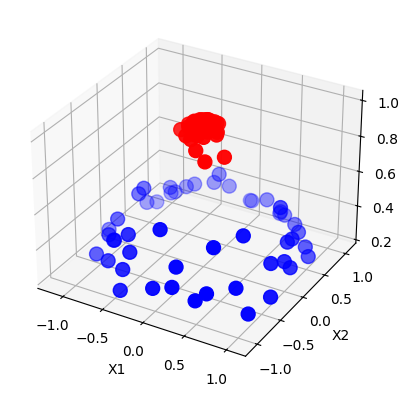

In [31]:
plot_3d_plot(X,y)

This block initializes another Support Vector Classifier, but this time with a Radial Basis Function (`rbf`) kernel. The RBF kernel implicitly maps the data into a higher-dimensional space (as visualized in the 3D plot) where it can find a linear decision boundary. The model is then trained on the training data and used to make predictions on the test data.

In [32]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

Finally, this block calculates the accuracy score for the RBF kernel SVM. As anticipated, the RBF kernel achieves a perfect accuracy of 1.0, demonstrating its effectiveness in handling non-linearly separable data like our concentric circles by transforming them into a higher-dimensional space where a linear separation is possible.

In [33]:
accuracy_score(y_test, y_pred)

1.0

In [34]:
print(f"First 5 RBF model predictions: {y_pred[:10]}")

First 5 RBF model predictions: [0 0 0 0 0 1 1 1 1 0]
